# Fusing two sensors at different rates

A vehicle carries a GPS receiver, which reports position once per second with a few meters
of noise, and wheel odometry, which reports velocity ten times per second with about
0.15 m/s of noise. Neither is good enough alone: GPS is noisy and slow, and
integrating odometry drifts without bound. One Kalman filter can use both, each through its
own measurement model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from kalman_py import KalmanFilter

rng = np.random.default_rng(7)

## Model and sensors

The state is `(px, py, vx, vy)` with a constant-velocity model at 10 Hz. Each sensor has its
own `H` (what it measures) and `R` (how noisy it is).

In [2]:
dt, q, steps = 0.1, 0.2, 1800  # 3 minutes at 10 Hz

F = np.eye(4)
F[0, 2] = F[1, 3] = dt
block = q * np.array([[dt**3 / 3, dt**2 / 2], [dt**2 / 2, dt]])
Q = np.zeros((4, 4))
Q[np.ix_([0, 2], [0, 2])] = block
Q[np.ix_([1, 3], [1, 3])] = block

H_gps, R_gps = np.hstack([np.eye(2), np.zeros((2, 2))]), 4.0**2 * np.eye(2)
H_odo, R_odo = np.hstack([np.zeros((2, 2)), np.eye(2)]), 0.15**2 * np.eye(2)
gps_every = 10  # GPS at 1 Hz

x0 = np.array([0.0, 0.0, 8.0, 0.0])
P0 = np.diag([5.0, 5.0, 1.0, 1.0]) ** 2

# Simulate the drive and both sensors.
x = rng.multivariate_normal(x0, P0)
truth, gps, odo = np.empty((steps, 4)), {}, np.empty((steps, 2))
for k in range(steps):
    x = F @ x + rng.multivariate_normal(np.zeros(4), Q)
    truth[k] = x
    odo[k] = H_odo @ x + rng.multivariate_normal(np.zeros(2), R_odo)
    if k % gps_every == gps_every - 1:
        gps[k] = H_gps @ x + rng.multivariate_normal(np.zeros(2), R_gps)

## Three filters

The model's default measurement is GPS. At every step the filter predicts; then it applies
whichever measurements arrived, passing `H` and `R` to `update` for the odometry. Two more
filters use one sensor each, for comparison.

In [3]:
def run(use_gps: bool, use_odometry: bool) -> np.ndarray:
    kf = KalmanFilter(F, H_gps, Q, R_gps, x0, P0)
    estimates = np.empty((steps, 4))
    for k in range(steps):
        kf.predict()
        if use_odometry:
            kf.update(odo[k], H=H_odo, R=R_odo)
        if use_gps and k in gps:
            kf.update(gps[k])  # the model's own H and R
        estimates[k] = kf.x
    return estimates


fused = run(use_gps=True, use_odometry=True)
gps_only = run(use_gps=True, use_odometry=False)
odometry_only = run(use_gps=False, use_odometry=True)


def position_error(estimates: np.ndarray) -> np.ndarray:
    return np.linalg.norm(estimates[:, :2] - truth[:, :2], axis=1)


for name, est in [
    ("GPS only", gps_only),
    ("odometry only", odometry_only),
    ("fused", fused),
]:
    err = position_error(est)
    rms = np.sqrt(np.mean(err**2))
    print(f"{name:14s} RMS error {rms:5.2f} m, final {err[-1]:5.2f} m")

GPS only       RMS error  3.58 m, final  2.19 m
odometry only  RMS error  2.33 m, final  1.89 m
fused          RMS error  0.92 m, final  0.08 m


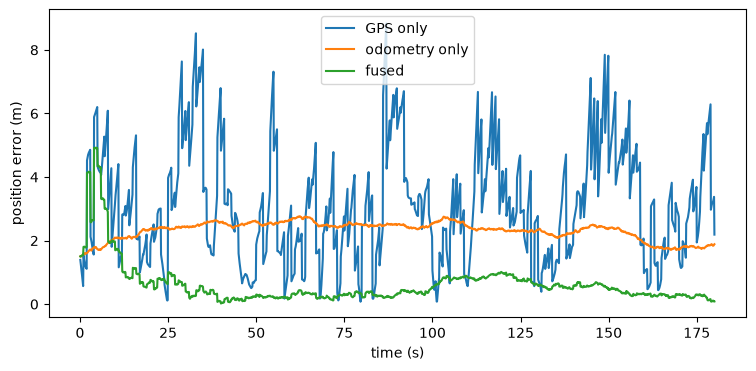

In [4]:
t = np.arange(1, steps + 1) * dt
fig, ax = plt.subplots(figsize=(9, 4))
for name, est in [
    ("GPS only", gps_only),
    ("odometry only", odometry_only),
    ("fused", fused),
]:
    ax.plot(t, position_error(est), label=name)
ax.set_xlabel("time (s)")
ax.set_ylabel("position error (m)")
ax.legend()
plt.show()

- **GPS only** has no long-term drift, but every estimate rests on noisy fixes that arrive
  once a second, so the error jumps around by meters.
- **Odometry only** is smooth, but nothing ever measures position: the initial position
  error is never corrected, and velocity errors integrate into a drift that nothing pulls
  back.
- **Fused**, odometry carries the estimate between GPS fixes and each fix pulls the position
  back, so the error has the smoothness of odometry without its drift and is the lowest of
  the three.

The same pattern works for any number of sensors and rates: one model for the dynamics, and
an `update(z, H=..., R=...)` per sensor reading. The measurement dimension can differ too,
for example a sensor that only reports heading.